> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib numpy


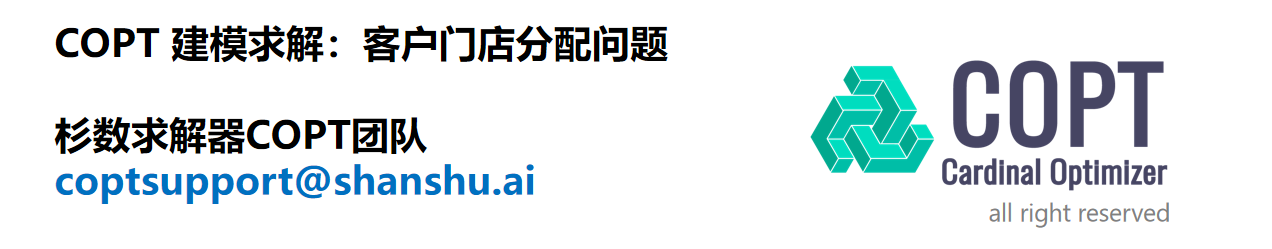

# 客户门店分配问题代码实现

## 使用COPT建模求解客户门店分配问题的步骤

1. **导入COPT-Python接口库** `coptpy`

2. **导入、预处理数据**
    - 导入客户对于门店的消费意愿数据
    - 构建辅助集合（如 `cus_store_grid`、`cus_expense_grid`）

3. **创建COPT求解环境与模型**

4. **构建模型：依次添加三要素**
    - **决策变量**：定义二进制决策变量 $x_{ij}$ ，表示客户 $i$ 是否被安排去商店 $j$；
    - **目标函数**：优先最大化客户数量，其次最大化总销售额；
    - **约束条件**：
        - 每一位客户最多去一家门店
        - 每一家门店容纳客户不超过其最大容量

5. **求解**

6. 查看、分析**结果**

## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT

import numpy as np
import matplotlib.pyplot as plt
import math

plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

## 添加模型数据


In [6]:
# 一共10位客户，4家门店
# [i, j, s] 代表客户 i 能够去门店 j 且会支付 s 元。
cus_store = [[0, 0, 10],
            [0, 2, 15],
            [0, 3, 5],
            [1, 1, 13],
            [1, 3, 15],
            [2, 0, 3],
            [2, 3, 5],
            [3, 0, 10],
            [3, 1, 10],
            [3, 2, 10],
            [3, 3, 10],
            [4, 1, 12],
            [5, 0, 20],
            [5, 2, 25],
            [6, 0, 11],
            [6, 1, 13],
            [6, 3, 14],
            [7, 2, 8],
            [7, 3, 9],
            [8, 0, 16],
            [8, 1, 14],
            [8, 3, 15],
            [9, 0, 9],
            [9, 1, 4],
            [9, 2, 8],
            [9, 3, 8]]
store_capacity = [4, 3, 2, 5]


## 数据预处理

In [8]:
# 获取客户数量与门店数量
num_cus = max(row[0] for row in cus_store) + 1
num_store = max(row[1] for row in cus_store) + 1

# 初始化客户与门店的邻接矩阵
cus_store_grid = np.zeros((num_cus, num_store))
cus_expense_grid = np.zeros((num_cus, num_store))
# 计算客户与门店邻接矩阵具体值
for row in cus_store:
    cus_store_grid[row[0]][row[1]] = 1
    cus_expense_grid[row[0]][row[1]] = row[2]

## 创建求解环境和求解模型

In [10]:
env = cp.Envr()
model_1 = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素
### 添加决策变量
$$
    x_{ij} = \begin{cases}
        1, & \text{将客户 $i$ 安排去门店 $j$} \\
        0, & \text{没有将客户 $i$ 安排去门店 $j$}
    \end{cases}
$$

In [12]:
x = model_1.addMVar((num_cus, num_store), vtype=COPT.BINARY, nameprefix="whether_customer_to_store")

### 设置多目标函数

**目标 1：最大化客户数量**

目标函数为最大化（ `sense=COPT.MAXIMIZE` ）进入门店的总客户数量，这是一个线性目标。
$$
    \max\sum_{i=0}^{num_{cus}-1}\sum_{j=0}^{num_{store}-1}x_{ij}
$$

In [14]:
model_1.setObjectiveN(
    1,
    sum(x),
    priority=2.0,
    sense=COPT.MAXIMIZE
)

**目标 2：最大化总销售额**

目标函数为最大化（ ``sense=COPT.MAXIMIZE`` ）所有门店的总销售额，这同样是一个线性目标。
$$
    \max\sum_{i=0}^{num_{cus}-1}\sum_{j=0}^{num_{store}-1}x_{ij}\cdot s_{ij}
$$

该目标用于在不影响客户数量最大化前提下，进一步最大化总销售额。我们将其设置为次要目标，并赋予较低的优先级（priority = 1）。

通过函数的入参 ``priority`` 为不同的目标指定优先级，COPT在求解时采用 **分层法** ，保证高优先级目标最优的基础上，优化次优先级的目标。

In [16]:
model_1.setObjectiveN(
    2,
    sum(x * cus_expense_grid),
    priority=1.0,
    sense=COPT.MAXIMIZE
)

<font color=#0000FF>
<b>提示：COPT多目标优化功能</b>
</font>   

COPT于7.2.8版本开始支持多目标优化功能，目前支持线性（连续或离散均可）的目标函数。通过调用Model类的成员方法 ``Model.setObjectiveN()`` 设置目标函数，并且可以为每个目标函数指定对应的优先级 ``priority`` 和权重 ``weight`` 等；在求解多目标模型时，COPT采用分层法（hierarchy method）和加权组合法（weighted-sum method）。具体请参考 [《COPT用户手册：多目标优化》](https://guide.coap.online/copt/zh-doc/multiobj.html)

### 添加约束条件

1. 每位客户最多进入一家店铺
$$
    \sum_{j=0}^{num_{store}-1}x_{ij} \leq 1, \quad \forall i=0, 1, \cdots, num_{cus} - 1
$$

In [20]:
model_1.addConstrs(sum(x[i]) <= 1 for i in range(num_cus))

2. 每家门店客户的数量不应超过其容量 
$$
    \sum_{i=0}^{num_{cus}-1}x_{ij} \leq c_j, \quad \forall j=0, 1, \cdots, num_{store} - 1
$$

In [22]:
model_1.addConstrs(cp.quicksum(x[i, j].item() for i in range(num_cus)) <= store_capacity[j] for j in range(num_store))

## 求解

In [24]:
model_1.solve()

Model fingerprint: 3da29448

Start the multi-objective optimization with 2 objectives

Using hierarchy method for 2 objective groups

Solving the 0-th objective group (priority=2)

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    14 rows, 40 columns and 80 non-zero elements
    40 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    14 rows, 40 columns and 80 non-zero elements
    40 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,5e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBo

## 获取结果

最优总人数为10.0人
最优总营业额为130.0元
客户安排如下：


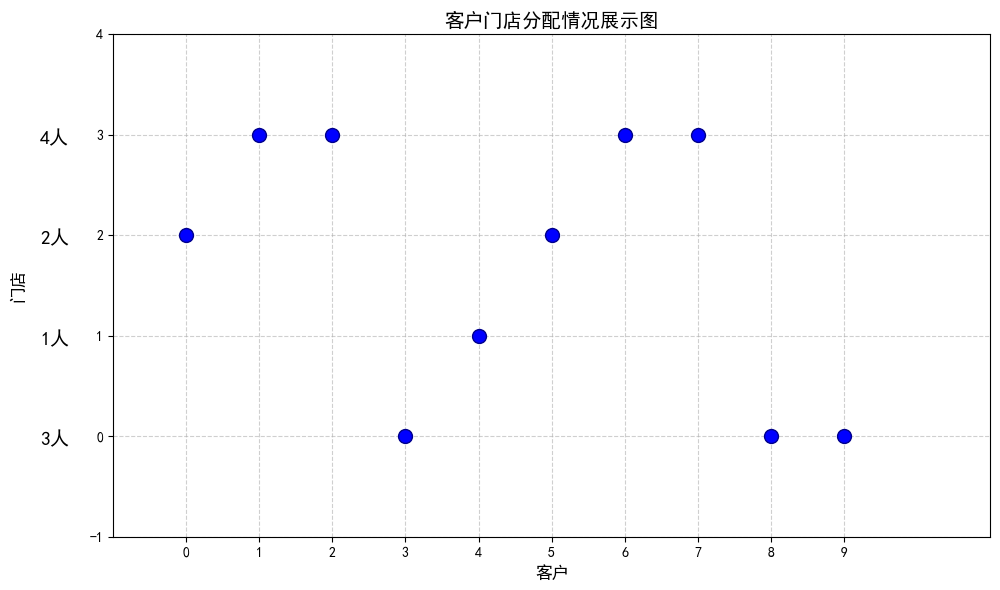

In [26]:
if model_1.status == COPT.OPTIMAL:
    print(f'最优总人数为{model_1.getAttrN(1, "BestObj")}人')
    print(f'最优总营业额为{model_1.getAttrN(2, "BestObj")}元')
    print('客户安排如下：')
    variables = model_1.getVars()
    solution_x = [[variables[i * num_store + j].x for j in range(num_store)] for i in range(num_cus)]
    answer = []
    num_actual = [0 for i in range(num_store)]
    for i in range(num_cus):
        if sum(solution_x[i][j] for j in range(num_store)) == 1:
            t = 0
            for k in range(num_store):
                if solution_x[i][k] == 1:
                    t = k
                    break
            answer.append([i, t])
            num_actual[t] += 1
        else:
            answer.append([i, -1])

    # 可视化
    fig, ax = plt.subplots(figsize=(10, 6))
    for i in range(num_cus):
        if answer[i][1] != -1:
            ax.scatter(answer[i][0], answer[i][1], marker='o', s=100, c='blue', edgecolor='darkblue', linewidth=1, zorder=5)
    for j in range(num_store):
        ax.text(-2, j - 0.09, f'{num_actual[j]}人', fontsize=14, color='black')
    ax.set_xlabel('客户', fontsize=12)
    ax.set_ylabel('门店', fontsize=12)
    ax.set_xticks(np.arange(0, num_cus, 1))
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_title('客户门店分配情况展示图', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim(-1, num_cus + 1)
    ax.set_ylim(-1, num_store)
    plt.tight_layout()
    plt.show()
else:
    print('未找到最优解')

# 添加权重参数的客户门店分配问题代码实现

整体步骤与原案例完全一致，仅模型部分出现变化，通过 `w` 来调整二者的权重，目标函数化为
$$
    \max\sum_{i=0}^{num_{cus}-1}\sum_{j=0}^{num_{store}-1}x_{ij} + \omega\sum_{i=0}^{num_{cus}-1}\sum_{j=0}^{num_{store}-1}x_{ij}\cdot s_{ij}
$$

## 创建求解环境和求解模型

我们在最开始的COPT环境中创建一个新的模型对象，用于表示带参数的优化模型。

In [29]:
model_2 = env.createModel()

## 添加模型三要素
### 添加决策变量
$$
    x_{ij} = \begin{cases}
        1, & \text{将客户 $i$ 安排去门店 $j$} \\
        0, & \text{没有将客户 $i$ 安排去门店 $j$}
    \end{cases}
$$

In [31]:
x = model_2.addMVar((num_cus, num_store), vtype=COPT.BINARY, nameprefix="whether_customer_to_store")

### 计算权重
`w` 通过对随机客户至随机可行门店的消费额求均值得到

In [33]:
w = 0
for item in cus_store:
    w += item[2]
w /= len(cus_store)

### 设置目标函数

通过权重参数 `w` 综合考虑两个目标
$$
    \max\sum_{i=0}^{num_{cus}-1}\sum_{j=0}^{num_{store}-1}x_{ij} + \omega\sum_{i=0}^{num_{cus}-1}\sum_{j=0}^{num_{store}-1}x_{ij}\cdot s_{ij}
$$

In [35]:
model_2.setObjective(sum(x) + w * sum(x * cus_expense_grid), sense = COPT.MAXIMIZE)

### 添加约束条件

1. 每位客户最多进入一家店铺
$$
    \sum_{j=0}^{num_{shop}-1}x_{ij} \leq 1, \quad \forall i=0, 1, \cdots, num_{cus} - 1
$$
2. 每家门店客户的数量不应超过其容量 
$$
    \sum_{i=0}^{num_{cus}-1}x_{ij} \leq c_j, \quad \forall j=0, 1, \cdots, num_{shop} - 1
$$

In [38]:
model_2.addConstrs(sum(x[i]) <= 1 for i in range(num_cus))
model_2.addConstrs(cp.quicksum(x[i, j].item() for i in range(num_cus)) <= store_capacity[j] for j in range(num_store))


## 求解

In [40]:
model_2.solve()

Model fingerprint: 65489985

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing a MIP problem

The original problem has:
    14 rows, 40 columns and 80 non-zero elements
    40 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    14 rows, 40 columns and 80 non-zero elements
    40 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,5e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [1e+00,3e+02]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  3.319385e+03            --     Inf  0.04s
H        0         1      --       0  3

## 获取结果

最优总人数为10.0 人
最优总营业额为130.0 元
客户安排如下：


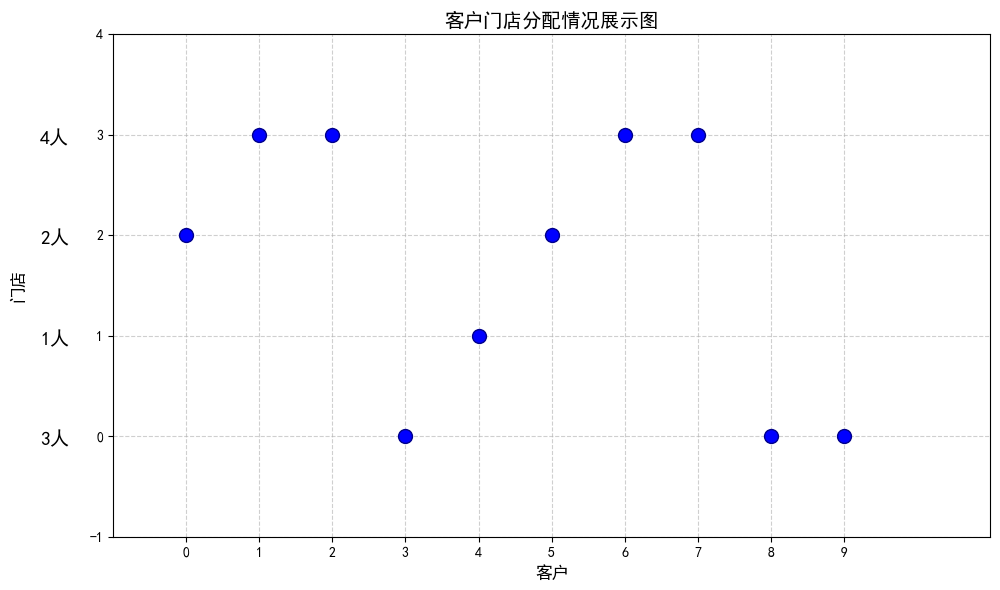

In [42]:
if model_2.status == COPT.OPTIMAL:
    variables = model_2.getVars()
    # 最优值显示需要同时改变
    print(f'最优总人数为{cp.quicksum(cp.quicksum(variables[i * num_store + j].x for j in range(num_store)) for i in range(num_cus))}人')
    print(f'最优总营业额为{cp.quicksum(cp.quicksum(variables[i * num_store + j].x * cus_expense_grid[i][j] for j in range(num_store)) for i in range(num_cus))}元')
    print('客户安排如下：')
    variables = model_2.getVars()
    solution_x = [[variables[i * num_store + j].x for j in range(num_store)] for i in range(num_cus)]
    answer = []
    num_actual = [0 for i in range(num_store)]
    for i in range(num_cus):
        if sum(solution_x[i][j] for j in range(num_store)) == 1:
            t = 0
            for k in range(num_store):
                if solution_x[i][k] == 1:
                    t = k
                    break
            answer.append([i, t])
            num_actual[t] += 1
        else:
            answer.append([i, -1])

    # 可视化
    fig, ax = plt.subplots(figsize=(10, 6))
    for i in range(num_cus):
        if answer[i][1] != -1:
            ax.scatter(answer[i][0], answer[i][1], marker='o', s=100, c='blue', edgecolor='darkblue', linewidth=1, zorder=5)
    for j in range(num_store):
        ax.text(-2, j - 0.09, f'{num_actual[j]}人', fontsize=14, color='black')
    ax.set_xlabel('客户', fontsize=12)
    ax.set_ylabel('门店', fontsize=12)
    ax.set_xticks(np.arange(0, num_cus, 1))
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_title('客户门店分配情况展示图', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim(-1, num_cus + 1)
    ax.set_ylim(-1, num_store)
    plt.tight_layout()
    plt.show()
else:
    print('未找到最优解')

# 添加最低营业标准的客户门店分配问题代码实现

整体步骤与原案例完全一致，仅模型部分出现变化，通过 `op_min` 来限制门店最低服务客户数，添加以下约束：
$$
    \sum_{i=0}^{num_{cus}-1}x_{ij} \geq h_j, \quad \forall j=0, 1, \cdots, num_{store} - 1
$$

## 创建求解环境和求解模型

我们在最开始的COPT环境中创建第三个模型对象，用于表示带有新约束的优化模型。

In [45]:
model_3 = env.createModel()

## 添加模型三要素
### 添加决策变量
$$
    x_{ij} = \begin{cases}
        1, & \text{将客户 $i$ 安排去门店 $j$} \\
        0, & \text{没有将客户 $i$ 安排去门店 $j$}
    \end{cases}
$$

In [47]:
x = model_3.addMVar((num_cus, num_store), vtype=COPT.BINARY, nameprefix="whether_customer_to_store")

### 计算最低营业水平
`op_min` 通过将总客户数量除以门店数量后再乘以 $\frac{1}{2}$ 上取整得到。

In [49]:
op_min = math.ceil(num_cus / num_store / 2)

### 设置多目标函数
设置多目标函数的方法在原模型中已解释，此处不再赘述

In [51]:
model_3.setObjectiveN(
    1,
    sum(x),
    priority=2.0,
    sense=COPT.MAXIMIZE
)
model_3.setObjectiveN(
    2,
    sum(x * cus_expense_grid),
    priority=1.0,
    sense=COPT.MAXIMIZE
)

1. 每位客户最多进入一家店铺
$$
    \sum_{j=0}^{num_{store}-1}x_{ij} \leq 1, \quad \forall i=0, 1, \cdots, num_{cus} - 1
$$
2. 每家门店客户的数量不应超过其容量 
$$
    \sum_{i=0}^{num_{cus}-1}x_{ij} \leq c_j, \quad \forall j=0, 1, \cdots, num_{store} - 1
$$
3. 每家门店客户的数量应超过最低营业水平
$$
    \sum_{i=0}^{num_{cus}-1}x_{ij} \geq op_min, \quad \forall j=0, 1, \cdots, num_{store} - 1
$$

In [53]:
model_3.addConstrs(sum(x[i]) <= 1 for i in range(num_cus))
model_3.addConstrs(cp.quicksum(x[i, j].item() for i in range(num_cus)) <= store_capacity[j] for j in range(num_store))
model_3.addConstrs(cp.quicksum(x[i, j].item() for i in range(num_cus)) >= op_min for j in range(num_store))


## 求解

In [55]:
model_3.solve()

Model fingerprint: e7ff3f1e

Start the multi-objective optimization with 2 objectives

Using hierarchy method for 2 objective groups

Solving the 0-th objective group (priority=2)

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    18 rows, 40 columns and 120 non-zero elements
    40 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    17 rows, 40 columns and 110 non-zero elements
    40 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,5e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]
    Density of cost:                     75.0%

     Nodes    Active  LPit/n  IntInf     BestB

## 获取结果

最优总人数为10.0人
最优总营业额为130.0元
最低营业水平为2人
客户安排如下：


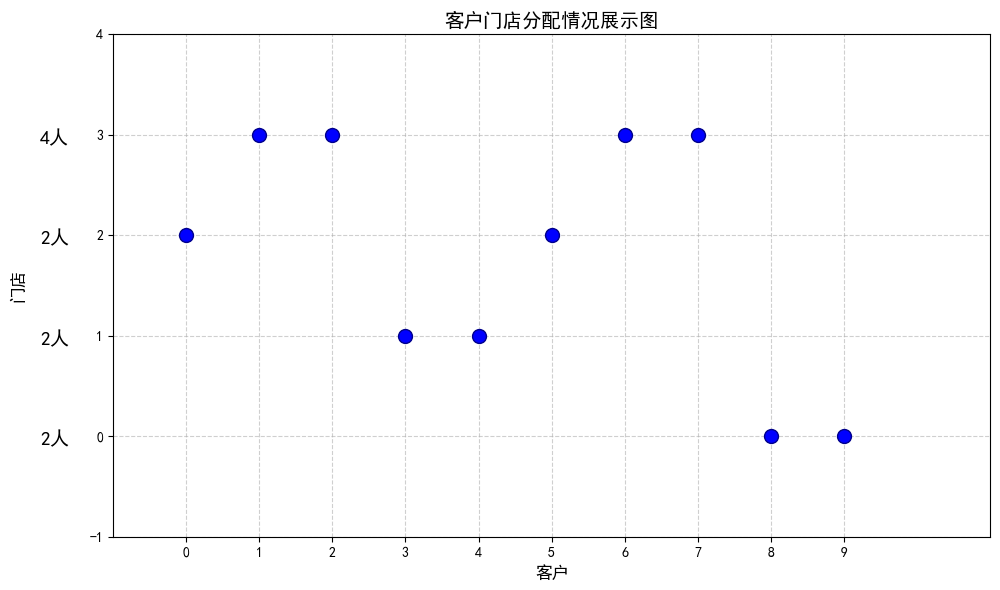

In [57]:
if model_3.status == COPT.OPTIMAL:
    print(f'最优总人数为{model_3.getAttrN(1, "BestObj")}人')
    print(f'最优总营业额为{model_3.getAttrN(2, "BestObj")}元')
    print(f'最低营业水平为{op_min}人')
    print('客户安排如下：')
    variables = model_3.getVars()
    solution_x = [[variables[i * num_store + j].x for j in range(num_store)] for i in range(num_cus)]
    answer = []
    num_actual = [0 for i in range(num_store)]
    for i in range(num_cus):
        if sum(solution_x[i][j] for j in range(num_store)) == 1:
            t = 0
            for k in range(num_store):
                if solution_x[i][k] == 1:
                    t = k
                    break
            answer.append([i, t])
            num_actual[t] += 1
        else:
            answer.append([i, -1])

    # 可视化
    fig, ax = plt.subplots(figsize=(10, 6))
    for i in range(num_cus):
        if answer[i][1] != -1:
            ax.scatter(answer[i][0], answer[i][1], marker='o', s=100, c='blue', edgecolor='darkblue', linewidth=1, zorder=5)
    for j in range(num_store):
        ax.text(-2, j - 0.09, f'{num_actual[j]}人', fontsize=14, color='black')
    ax.set_xlabel('客户', fontsize=12)
    ax.set_ylabel('门店', fontsize=12)
    ax.set_xticks(np.arange(0, num_cus, 1))
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_title('客户门店分配情况展示图', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim(-1, num_cus + 1)
    ax.set_ylim(-1, num_store)
    plt.tight_layout()
    plt.show()
else:
    print('未找到最优解')